## ARIMA For Process Behavior Estimation using the Box-Jenkins Method
### CPU Intensive GP Workloads
#### Braden Everson

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import math

In [2]:
series = pd.read_csv("../gp-workloads/time_slices/cpu_intensive_2/cpu_intensive_2_waitrun_5000us.csv")
# series = pd.read_csv("../gp-workloads/time_slices/cpu_intensive_7/cpu_intensive_7_waitrun_5000us.csv")
# series = pd.read_csv("../gp-workloads/time_slices/cpu_intensive_12/cpu_intensive_12_waitrun_500us.csv")

In [3]:
series

,bin_index,start_time_us,end_time_us,waiting_time_us,running_time_us,waiting_pct,running_pct
0,0,0,5000,300,4700,6.000000,94.000000
1,1,5000,10000,202,4798,4.040000,95.960000
2,2,10000,15000,127,4873,2.540000,97.460000
3,3,15000,20000,116,4884,2.320000,97.680000
4,4,20000,25000,124,4876,2.480000,97.520000
...,...,...,...,...,...,...,...
211,211,1055000,1060000,312,4688,6.240000,93.760000
212,212,1060000,1065000,373,4627,7.460000,92.540000
213,213,1065000,1070000,290,4710,5.800000,94.200000
214,214,1070000,1075000,295,4705,5.900000,94.100000


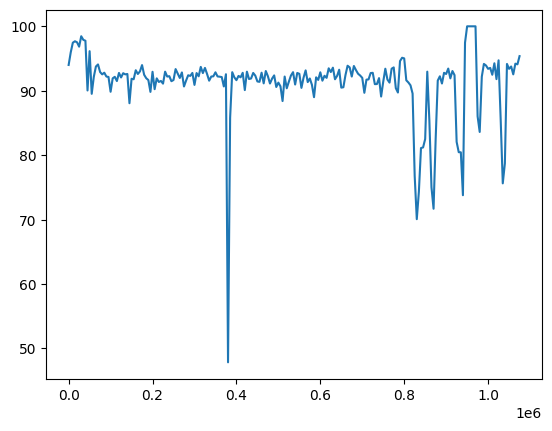

In [4]:
plt.plot(series["start_time_us"], series["running_pct"])

## ARIMA to Predict the final value

In [5]:
model = ARIMA(series["running_pct"], order=(5, 1, 0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=1)
print(f"Predicted running_pct: {forecast.iloc[0]:.2f}")

Predicted running_pct: 94.68


## ARIMA at "run-time", collecting deltas off as we go

In [6]:
pred = []

for i in range(5, len(series["running_pct"])):
    model = ARIMA(series["running_pct"][0:i], order=(5, 1, 0))
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=1).iloc[0]
    pred.append(forecast)

/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_r

In [7]:
len(pred)

211

In [8]:
len(series["running_pct"])

216

We don't start with any predictions before we have at least 5 samples to look back to, let's just assume 50% CPU utilization is the placeholder for these cases

In [9]:
padding = [50,50,50,50,50]

pred = padding + pred

Text(0.5, 1.0, 'Actual Running Percentage')

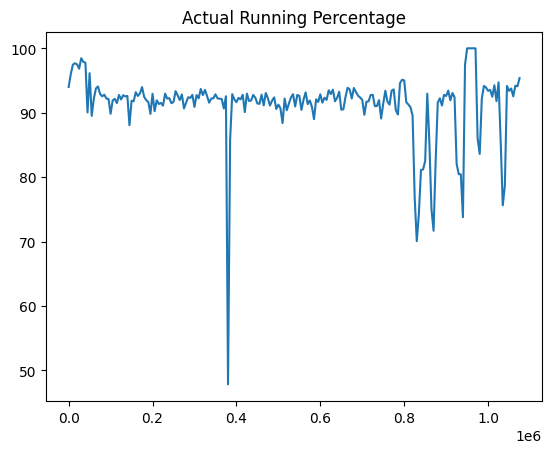

In [10]:
plt.plot(series["start_time_us"], series["running_pct"])
plt.title("Actual Running Percentage")

Text(0.5, 1.0, 'Predicted Running Percentage')

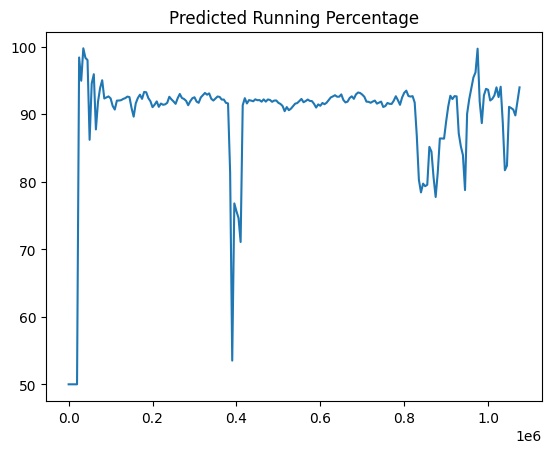

In [11]:
plt.plot(series["start_time_us"], pred)
plt.title("Predicted Running Percentage")

In [12]:
pred_arr = np.array(pred)
off = series["running_pct"] - pred_arr

Text(0.5, 1.0, 'Actual - Predicted Running Percentage')

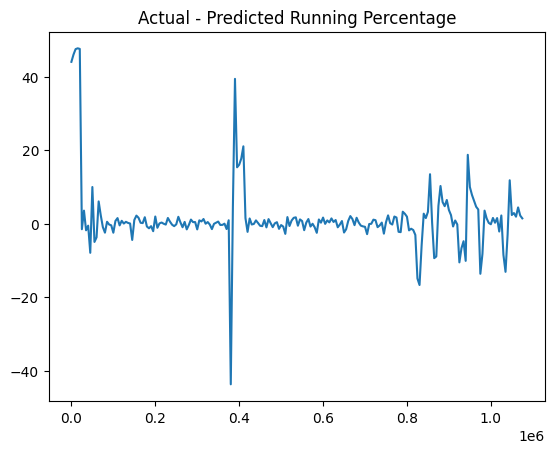

In [13]:
plt.plot(series["start_time_us"], off)

plt.title("Actual - Predicted Running Percentage")

In general, *close* but never exactly there. Spikes are properly seen but are never the same magnitude as the true spikes down

In [14]:
rmse = math.sqrt((off ** 2).sum() / len(off))

print(f"RMSE: {rmse:.2f}")

RMSE: 9.33


### Sliding Window Based Approach

In [15]:
pred = []
WINDOW = 12

for i in range(WINDOW, len(series["running_pct"])):
    model = ARIMA(series["running_pct"][i-WINDOW:i], order=(5, 1, 0))
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=1).iloc[0]
    pred.append(forecast)

/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/braden/csc4601/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary star

In [16]:
len(pred)

204

In [17]:
padding = [50] * WINDOW

pred = padding + pred

Text(0.5, 1.0, 'Predicted Running Percentage')

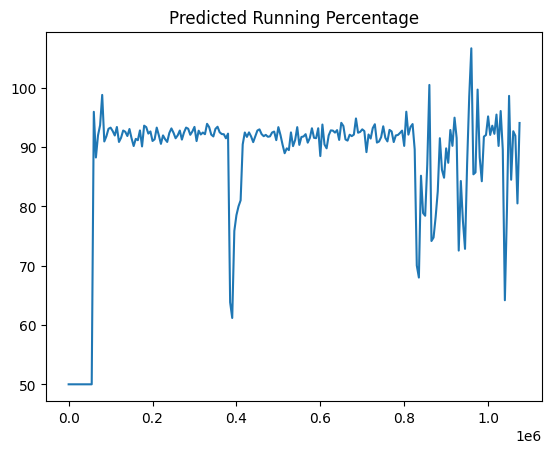

In [18]:
plt.plot(series["start_time_us"], pred)
plt.title("Predicted Running Percentage")

In [19]:
pred_arr = np.array(pred)
off = series["running_pct"][WINDOW:] - pred_arr[WINDOW:]

In [20]:
rmse = math.sqrt((off ** 2).sum() / len(off))

print(f"RMSE: {rmse:.2f}")

RMSE: 6.36


Not much worse than the full history rmse!